In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.append('../src')
from url_parser import URLParser

In [2]:
df = pd.read_csv('../data/phishing_site_urls.csv')
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nSample rows:")
df.head(5)

Shape: (549346, 2)
Columns: ['URL', 'Label']

Sample rows:


,URL,Label
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,bad
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad
3,mail.printakid.com/www.online.americanexpress....,bad
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad


Label
good    392924
bad     156422
Name: count, dtype: int64


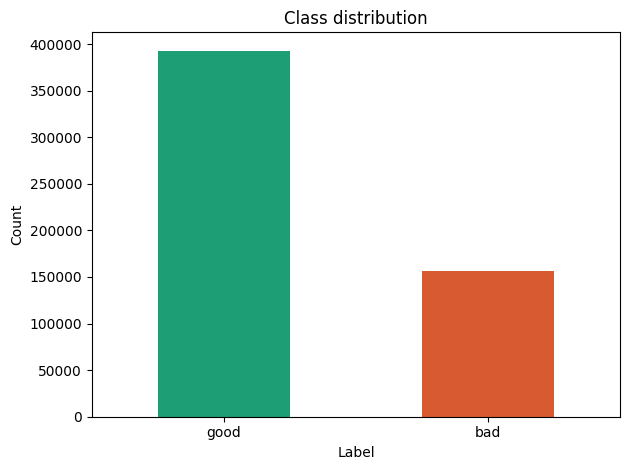

In [3]:
counts = df['Label'].value_counts()
print(counts)

counts.plot(kind='bar', color=['#1D9E75', '#D85A30'], edgecolor='none')
plt.title('Class distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [4]:
df['label'] = df['Label'].map({'good': 0, 'bad': 1})
print("After mapping:")
print(df['label'].value_counts())
print("\nAny nulls?", df['label'].isnull().sum())

After mapping:
label
0    392924
1    156422
Name: count, dtype: int64

Any nulls? 0


In [5]:
df['url_length'] = df['URL'].str.len()

print("=== URL Length Stats ===")
print("\nPhishing URLs:")
print(df[df['label']==1]['url_length'].describe().round(1))
print("\nBenign URLs:")
print(df[df['label']==0]['url_length'].describe().round(1))

=== URL Length Stats ===

Phishing URLs:
count    156422.0
mean         63.2
std          72.0
min           1.0
25%          26.0
50%          40.0
75%          72.0
max        2307.0
Name: url_length, dtype: float64

Benign URLs:
count    392924.0
mean         45.8
std          24.6
min           1.0
25%          30.0
50%          40.0
75%          56.0
max        1025.0
Name: url_length, dtype: float64


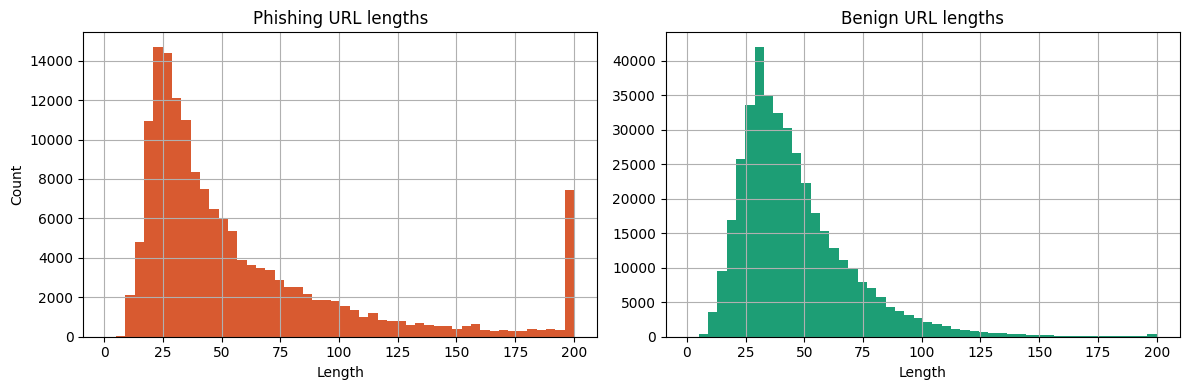

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df[df['label']==1]['url_length'].clip(upper=200).hist(
    bins=50, ax=axes[0], color='#D85A30', edgecolor='none')
axes[0].set_title('Phishing URL lengths')
axes[0].set_xlabel('Length')
axes[0].set_ylabel('Count')

df[df['label']==0]['url_length'].clip(upper=200).hist(
    bins=50, ax=axes[1], color='#1D9E75', edgecolor='none')
axes[1].set_title('Benign URL lengths')
axes[1].set_xlabel('Length')

plt.tight_layout()
plt.show()

In [7]:
sample_phishing = df[df['label']==1]['URL'].head(3).tolist()
sample_benign = df[df['label']==0]['URL'].head(3).tolist()

print("=== Phishing URL Parsing ===")
for url in sample_phishing:
    parsed = URLParser(url).parse()
    print(f"URL: {url[:60]}...")
    print(f"  TLD: {parsed['tld']}  |  Subdomains: {parsed['subdomains']}  |  Path: {parsed['path'][:30]}")
    print()

print("=== Benign URL Parsing ===")
for url in sample_benign:
    parsed = URLParser(url).parse()
    print(f"URL: {url[:60]}...")
    print(f"  TLD: {parsed['tld']}  |  Subdomains: {parsed['subdomains']}  |  Path: {parsed['path'][:30]}")
    print()

=== Phishing URL Parsing ===
URL: nobell.it/70ffb52d079109dca5664cce6f317373782/login.SkyPe.co...
  TLD: .it  |  Subdomains: []  |  Path: 70ffb52d079109dca5664cce6f3173

URL: www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrcmd=_home-custo...
  TLD: .com  |  Subdomains: ['www']  |  Path: paypal.co.uk/cycgi-bin/webscrc

URL: serviciosbys.com/paypal.cgi.bin.get-into.herf.secure.dispatc...
  TLD: .com  |  Subdomains: []  |  Path: paypal.cgi.bin.get-into.herf.s

=== Benign URL Parsing ===
URL: esxcc.com/js/index.htm?us.battle.net/noghn/en/?ref5M+9d'bbws...
  TLD: .com  |  Subdomains: []  |  Path: js/index.htm

URL: wwweira¯&nvinip¿ncH¯wVö%ÆåyDaHðû/ÏyEùuË
Ó6(rTÃuæ=g...
  TLD: unknown  |  Subdomains: []  |  Path: ïyeùuë
ó6(rtãuæ=g0¾

URL: 'www.institutocgr.coo/web/media/syqvem/dk-óij!R\gr0âÕ5dfe<...
  TLD: .coo  |  Subdomains: ["'www"]  |  Path: web/media/syqvem/dk-óij!r\gr



In [8]:
df_clean = df[['URL', 'label']].rename(columns={'URL': 'url'})
df_clean.to_csv('../data/raw_urls.csv', index=False)
print(f"Saved {len(df_clean)} URLs to data/raw_urls.csv")
print(f"Phishing: {(df_clean['label']==1).sum()}")
print(f"Benign:   {(df_clean['label']==0).sum()}")

Saved 549346 URLs to data/raw_urls.csv
Phishing: 156422
Benign:   392924


## Key observations

- Dataset contains 549,346 URLs — 392,924 benign and 156,422 phishing
- Phishing URLs tend to be longer on average
- Phishing URLs frequently contain suspicious TLDs and deep subdomain nesting
- Class imbalance (~71% benign, ~29% phishing) — will handle with class_weight during training